In [2]:
import pandas as pd
df = pd.read_csv('dataset.csv')

In [3]:
df.head()

,Unnamed: 0,DATE,Month,Year,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME_1,Brand,PACK_SIZE,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,0,2018-10-17,October,2018,1,1000,1,5,Natural Chip Company Chip Compny SeaSalt175g,Natural Chip Company,175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,1,2019-05-14,May,2019,1,1307,348,66,CCs Nacho Cheese 175g,CCs,175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2,2019-05-20,May,2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,Smiths,170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,3,2018-08-17,August,2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,Smiths,175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,4,2018-08-18,August,2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle,150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [4]:
df['DATE']=pd.to_datetime(df['DATE'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264835 entries, 0 to 264834
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Unnamed: 0        264835 non-null  int64         
 1   DATE              264835 non-null  datetime64[ns]
 2   Month             264835 non-null  object        
 3   Year              264835 non-null  int64         
 4   STORE_NBR         264835 non-null  int64         
 5   LYLTY_CARD_NBR    264835 non-null  int64         
 6   TXN_ID            264835 non-null  int64         
 7   PROD_NBR          264835 non-null  int64         
 8   PROD_NAME_1       264835 non-null  object        
 9   Brand             264835 non-null  object        
 10  PACK_SIZE         264835 non-null  object        
 11  PROD_QTY          264835 non-null  int64         
 12  TOT_SALES         264835 non-null  float64       
 13  LIFESTAGE         264835 non-null  object        
 14  PREM

In [25]:
tot=df['TOT_SALES'].sum()
print(f'{tot:,.2f}')

1,805,171.70


In [6]:
df['PROD_NAME_1'].head(20)

0          Natural Chip Company Chip Compny SeaSalt175g
1                                 CCs Nacho Cheese 175g
2                 Smiths Crinkle Cut Chips Chicken 170g
3                 Smiths Chip Thinly S/Cream&Onion 175g
4              Kettle Tortilla ChpsHny&Jlpno Chili 150g
5        Old El Paso El Paso Salsa Dip Tomato Mild 300g
6              Smiths Crinkle Chips Salt & Vinegar 330g
7                   Grain Waves Waves Sweet Chilli 210g
8               Doritos Corn Chip Mexican Jalapeno 150g
9              Grain Waves Waves Sour Cream&Chives 210G
10             Smiths Crinkle Chips Salt & Vinegar 330g
11                  Kettle Sensations Siracha Lime 150g
12                                 Twisties Cheese 270g
13                  Woolworths Crinkle Cut Chicken 175g
14                        Thins Chips Light& Tangy 175g
15                                    CCs Original 175g
16                                    Burger Rings 220g
17    Natural Chip Company Sour Cream & Garden C

In [7]:
words=(df['PROD_NAME_1'].drop_duplicates().str.split( ).explode())
words

0      Natural
0         Chip
0      Company
0         Chip
0       Compny
        ...   
549       150g
689    Doritos
689      Salsa
689       Mild
689       300g
Name: PROD_NAME_1, Length: 617, dtype: object

In [8]:
product_words = words.to_frame(name='words')

In [9]:
product_words = product_words[product_words['words'].str.fullmatch(r'[A-Za-z]+')]
product_words

,words
0,Natural
0,Chip
0,Company
0,Chip
0,Compny
...,...
549,Cut
549,Bolognese
689,Doritos
689,Salsa


In [10]:
product_words.groupby(['words'])['words'].count().sort_values(ascending=False)


words
Chips      21
Smiths     16
Crinkle    14
Chip       14
Cut        14
           ..
Vinegr      1
Whlegrn     1
Vingar      1
Whlgrn      1
saltd       1
Name: words, Length: 164, dtype: int64

In [11]:
product_words['words'].unique()

array(['Natural', 'Chip', 'Company', 'Compny', 'CCs', 'Nacho', 'Cheese',
       'Smiths', 'Crinkle', 'Cut', 'Chips', 'Chicken', 'Thinly', 'Kettle',
       'Tortilla', 'Chili', 'Old', 'El', 'Paso', 'Salsa', 'Dip', 'Tomato',
       'Mild', 'Salt', 'Vinegar', 'Grain', 'Waves', 'Sweet', 'Chilli',
       'Doritos', 'Corn', 'Mexican', 'Jalapeno', 'Sour', 'Sensations',
       'Siracha', 'Lime', 'Twisties', 'Woolworths', 'Thins', 'Tangy',
       'Original', 'Burger', 'Rings', 'Cream', 'Garden', 'Chives',
       'Southern', 'Cheezels', 'Box', 'Infuzions', 'Crn', 'Crnchers',
       'Gcamole', 'Sea', 'And', 'Red', 'Rock', 'Deli', 'Thai', 'Pringles',
       'Sthrn', 'FriedChicken', 'BBQ', 'SR', 'Mzzrlla', 'Originl',
       'saltd', 'Sp', 'Truffle', 'Swt', 'Mexicana', 'French', 'OnionDip',
       'ChipCo', 'Hony', 'Soy', 'Chp', 'Supreme', 'Roast', 'Mozzarella',
       'Basil', 'Pesto', 'SweetChili', 'PotatoMix', 'Camembert', 'Fig',
       'smiths', 'Mac', 'N', 'Honey', 'Seasonedchicken', 'Rib', 'Pr

In [12]:
df=df[~df['PROD_NAME_1'].str.contains("SALSA",case=False)]

In [13]:
df.head()

,Unnamed: 0,DATE,Month,Year,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME_1,Brand,PACK_SIZE,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,0,2018-10-17,October,2018,1,1000,1,5,Natural Chip Company Chip Compny SeaSalt175g,Natural Chip Company,175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,1,2019-05-14,May,2019,1,1307,348,66,CCs Nacho Cheese 175g,CCs,175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2,2019-05-20,May,2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,Smiths,170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,3,2018-08-17,August,2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,Smiths,175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,4,2018-08-18,August,2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle,150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [14]:
df.groupby(['LYLTY_CARD_NBR'])['PROD_QTY'].sum().sort_values(ascending=False)

LYLTY_CARD_NBR
226000    400
230078     36
162039     34
179228     32
116181     32
         ... 
1024        1
1023        1
1022        1
1019        1
1009        1
Name: PROD_QTY, Length: 71288, dtype: int64

In [15]:
df=df[df['LYLTY_CARD_NBR']!= 226000 ]

<Axes: xlabel='DATE'>

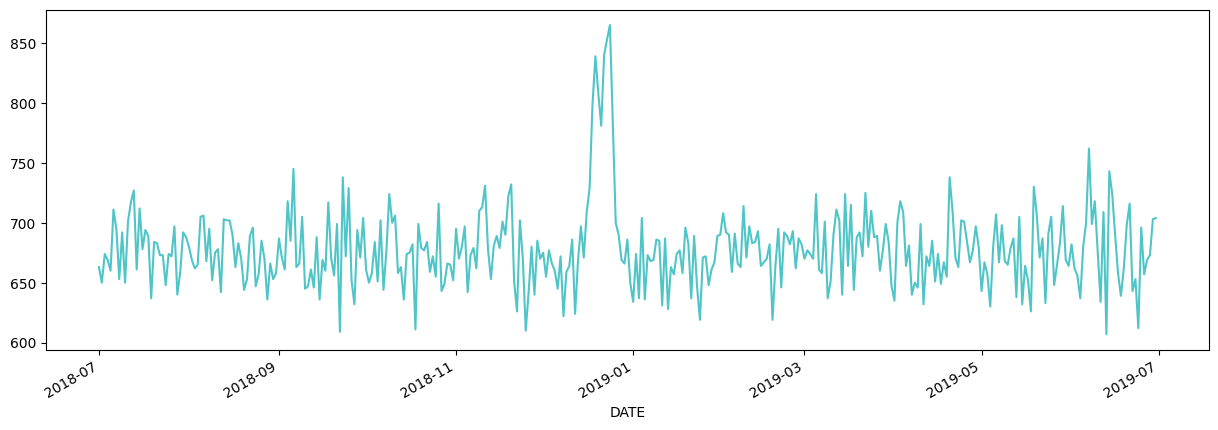

In [36]:
import matplotlib.pyplot as plt 
df.groupby(['DATE'])['TXN_ID'].count().plot(kind='line',figsize=(15,5),color = '#50c5c7')

<Axes: xlabel='DATE'>

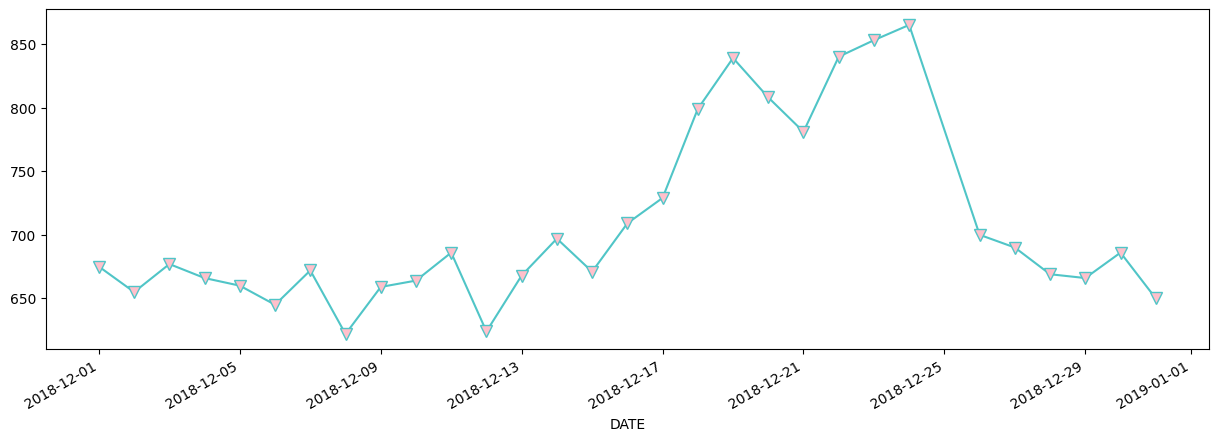

In [17]:
dec=df[df['DATE'].dt.month==12]
dec.groupby(df['DATE'])['TXN_ID'].count().plot(kind='line',figsize=(15,5),color = '#50c5c7',marker="v",markersize=9,markerfacecolor='pink')

<Axes: ylabel='Frequency'>

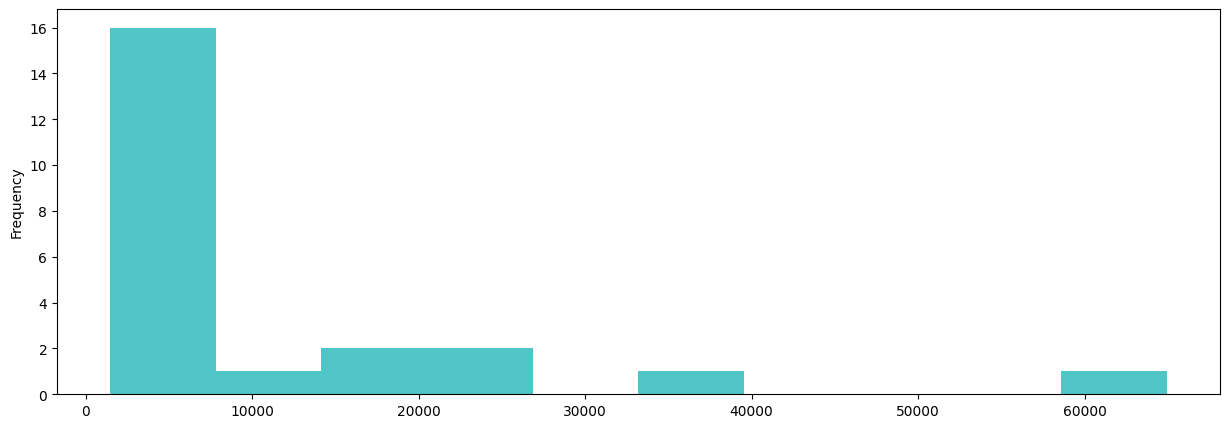

In [18]:
df.groupby(df['PACK_SIZE'])['TXN_ID'].count().plot(kind='hist',figsize=(15,5),color = '#50c5c7')

In [19]:
print(df.groupby(df['Brand'])['TOT_SALES'].sum().sort_values(ascending = False).apply(lambda x : f"₹{x:,.2f}")) 

Brand
Kettle                  ₹390,239.80
Doritos                 ₹226,329.90
Smiths                  ₹202,902.60
Pringles                ₹177,655.50
Infuzions                ₹99,047.60
Thins                    ₹88,852.50
Twisties                 ₹81,522.10
Tostitos                 ₹79,789.60
Cobs                     ₹70,569.80
RRD                      ₹64,954.50
Tyrrells                 ₹51,647.40
Grain Waves              ₹43,044.20
Natural Chip Company     ₹42,318.00
Woolworths               ₹41,059.10
Cheezels                 ₹40,029.90
Red Rock Deli            ₹22,653.00
CCs                      ₹18,078.90
Cheetos                  ₹16,884.50
smiths                   ₹14,583.40
Grain Waves Waves         ₹8,546.70
French                    ₹7,929.00
Burger                    ₹6,831.00
Snbts                     ₹5,076.20
Sunbites                  ₹4,600.20
Grain Waves                  ₹26.30
Name: TOT_SALES, dtype: object


<Axes: title={'center': 'Total sales by Brand'}, xlabel='Brand'>

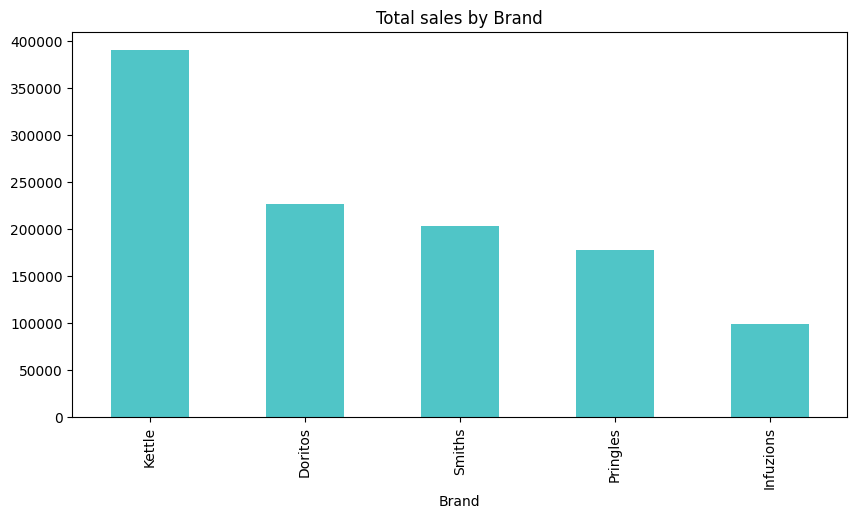

In [51]:
df.groupby(df['Brand'])['TOT_SALES'].sum().sort_values(ascending=False).head(5).plot(kind='bar',title = 'Total sales by Brand',color='#50c5c7',figsize=(10,5))

In [57]:
top5_pct = (
    df.groupby('Brand')['TOT_SALES']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .sum()
      / df['TOT_SALES'].sum()
      * 100
)

print(f'Percentage of sales for top five brands : {top5_pct:.2f}%')

Percentage of sales for top five brands : 60.72%


In [58]:
top5_sale = (
    df.groupby('Brand')['TOT_SALES']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .sum()
)

print(f'Total sales for top five brands : {top5_sale:.2f}')

Total sales for top five brands : 1096175.40


In [21]:
df.groupby(df['PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False).apply(lambda x : f"₹{x:,.2f}")

PREMIUM_CUSTOMER
Mainstream    ₹700,865.40
Budget        ₹631,406.85
Premium       ₹472,899.45
Name: TOT_SALES, dtype: object

In [22]:
df.groupby(df['PACK_SIZE'])['TOT_SALES'].sum().sort_values(ascending = False).apply(lambda x : f"₹{x:,.2f}")

PACK_SIZE
175g    ₹477,106.40
150g    ₹282,003.00
134g    ₹177,655.50
110g    ₹162,765.40
170g    ₹146,673.00
330g    ₹136,794.30
165g    ₹101,360.60
380g     ₹75,419.60
270g     ₹55,425.40
250g     ₹26,096.70
Salt     ₹26,090.40
210g     ₹21,700.80
210G     ₹21,348.00
200g     ₹16,007.50
190g     ₹14,412.90
160g     ₹10,647.60
 90g      ₹9,676.40
180g      ₹8,568.40
175G      ₹8,325.00
150G      ₹7,678.80
 70g      ₹6,852.00
220g      ₹6,831.00
125g      ₹5,733.00
Name: TOT_SALES, dtype: object

<Axes: title={'center': 'Total Sales by Lifestage'}, xlabel='LIFESTAGE'>

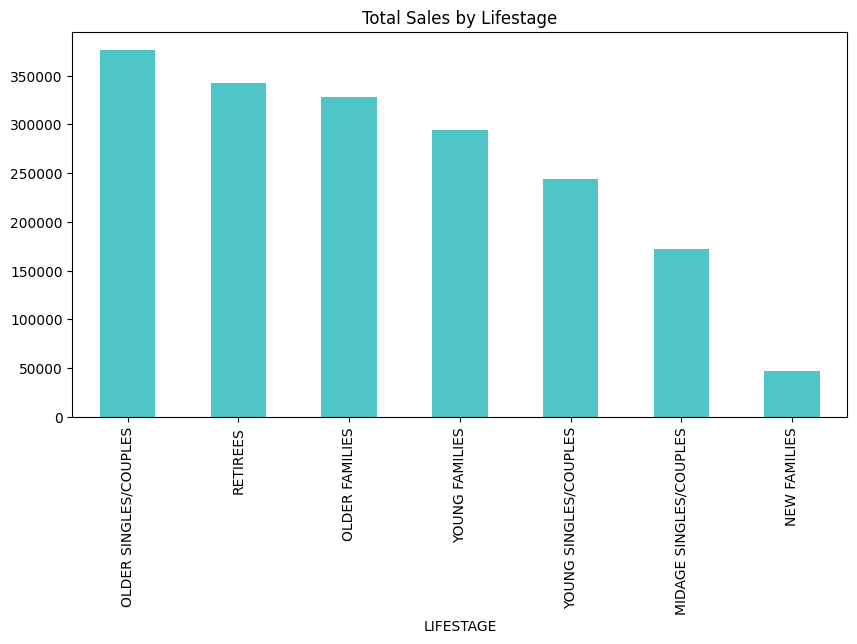

In [23]:

df.groupby(df['LIFESTAGE'])['TOT_SALES'].sum().sort_values(ascending=False).plot(kind='bar',title='Total Sales by Lifestage',color = '#50c5c7',figsize=(10,5))

In [26]:
avg_unit=(df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg(PROD_QTY=('PROD_QTY','sum'),
                                                          unique_cus = ('LYLTY_CARD_NBR','nunique')))

avg_unit['avg_unit_cus']=(avg_unit['PROD_QTY'] / avg_unit['unique_cus'])

avg_unit


PROD_QTY  unique_cus  avg_unit_cus
LIFESTAGE              PREMIUM_CUSTOMER                                    
MIDAGE SINGLES/COUPLES Budget                8883        1474      6.026459
                       Mainstream           21213        3298      6.432080
                       Premium              14400        2369      6.078514
NEW FAMILIES           Budget                5241        1087      4.821527
                       Mainstream            4060         830      4.891566
                       Premium               2769         575      4.815652
OLDER FAMILIES         Budget               41853        4611      9.076773
                       Mainstream           25804        2788      9.255380
                       Premium              20239        2231      9.071717
OLDER SINGLES/COUPLES  Budget               32883        4849      6.781398
                       Mainstream           32607        4858      6.712021
                       Premium              31693        4682      6.769116
RETIREES               Budget               26932        4385      6.141847
                       Mainstream           37677        6358      5.925920
                       Premium              23266        3812      6.103358
YOUNG FAMILIES         Budget               34482        3953      8.722995
                       Mainstream           23194        2685      8.638361
                       Premium              20901        2398      8.716013
YOUNG SINGLES/COUPLES  Budget               15500        3647      4.250069
                       Mainstream           36225        7917      4.575597
                       Premium              10575        2480      4.264113

<Axes: title={'center': 'Average Units per Customer by Lifestage and Premium Customer'}, xlabel='LIFESTAGE'>

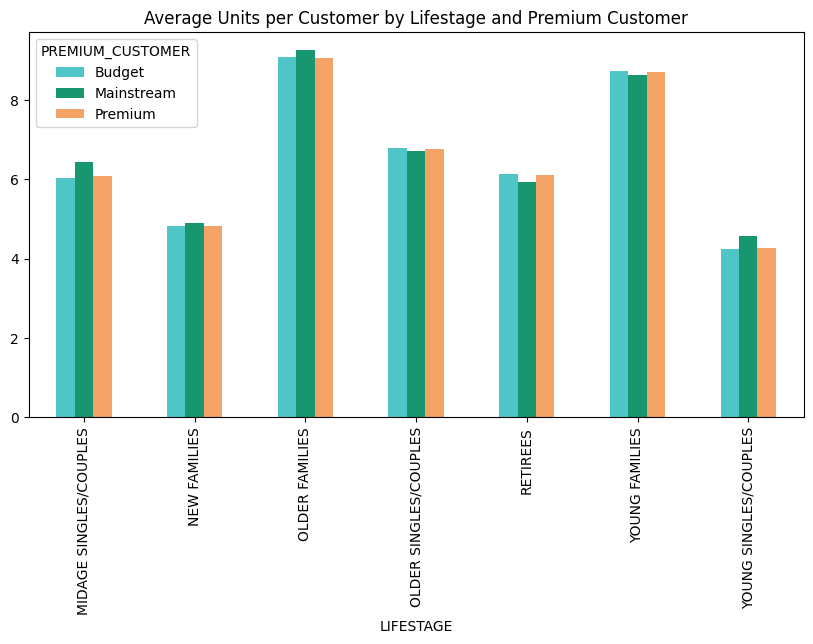

In [47]:
avg_unit['avg_unit_cus'].unstack().plot(kind='bar',figsize=(10,5),legend=True,title='Average Units per Customer by Lifestage and Premium Customer',color = ['#50c5c7','#18966f','#f2a365'])

In [28]:
avg_price=(df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg(total_sales=('TOT_SALES','sum'),
                                                          unique_cus = ('LYLTY_CARD_NBR','nunique')))

avg_price['avg_price_cus']=(avg_price['total_sales'] / avg_price['unique_cus'])

avg_price


total_sales  unique_cus  \
LIFESTAGE              PREMIUM_CUSTOMER                            
MIDAGE SINGLES/COUPLES Budget               33345.70        1474   
                       Mainstream           84734.25        3298   
                       Premium              54443.85        2369   
NEW FAMILIES           Budget               20607.45        1087   
                       Mainstream           15979.70         830   
                       Premium              10760.80         575   
OLDER FAMILIES         Budget              156863.75        4611   
                       Mainstream           96413.55        2788   
                       Premium              75242.60        2231   
OLDER SINGLES/COUPLES  Budget              127833.60        4849   
                       Mainstream          124648.50        4858   
                       Premium             123531.55        4682   
RETIREES               Budget              105916.30        4385   
                       Mainstream          145168.95        6358   
                       Premium              91296.65        3812   
YOUNG FAMILIES         Budget              129717.95        3953   
                       Mainstream           86338.25        2685   
                       Premium              78571.70        2398   
YOUNG SINGLES/COUPLES  Budget               57122.10        3647   
                       Mainstream          147582.20        7917   
                       Premium              39052.30        2480   

                                         avg_price_cus  
LIFESTAGE              PREMIUM_CUSTOMER                 
MIDAGE SINGLES/COUPLES Budget                22.622592  
                       Mainstream            25.692617  
                       Premium               22.981786  
NEW FAMILIES           Budget                18.958096  
                       Mainstream            19.252651  
                       Premium               18.714435  
OLDER FAMILIES         Budget                34.019464  
                       Mainstream            34.581618  
                       Premium               33.725952  
OLDER SINGLES/COUPLES  Budget                26.362879  
                       Mainstream            25.658399  
                       Premium               26.384355  
RETIREES               Budget                24.154230  
                       Mainstream            22.832487  
                       Premium               23.949803  
YOUNG FAMILIES         Budget                32.815065  
                       Mainstream            32.155773  
                       Premium               32.765513  
YOUNG SINGLES/COUPLES  Budget                15.662764  
                       Mainstream            18.641177  
                       Premium               15.746895

<Axes: xlabel='LIFESTAGE'>

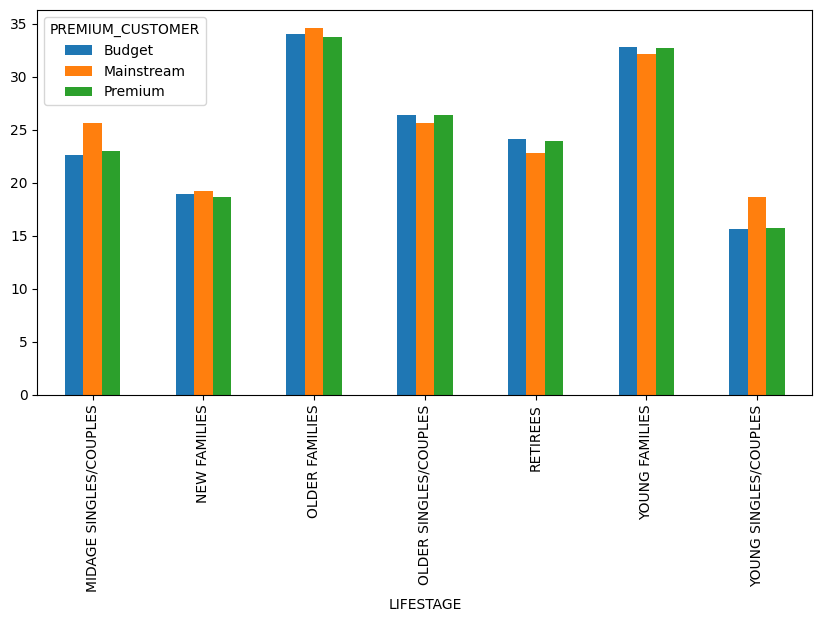

In [29]:
avg_price['avg_price_cus'].unstack().plot(kind='bar',figsize=(10,5))

SUMMARY

TOTAL_CHIP_SALES = ₹1,805,171.70 

Highly saled Pack_sizes = 175g, 150g, 134g

Frequent Customer = Older singles/couples

High revenue Month = December

-> The results suggest that sales are not evenly distributed across all products and customer groups. 
-> A small number of brands, customer segments, and pack sizes appear to drive a large share of revenue. 
-> This indicates that focused marketing and inventory planning could improve business performance.
-> Prioritize high-performing brands and expand promotional support around them.